In [13]:
# Install any missing libraries
!pip install kaggle pandas numpy matplotlib seaborn scikit-learn torch torchvision -q

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

All libraries loaded
PyTorch version: 2.10.0+cu128
GPU available: True


In [15]:
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and select AmesHousing.csv

Saving AmesHousing 2.csv to AmesHousing 2.csv


In [16]:
import pandas as pd
df = pd.read_csv("AmesHousing.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [17]:
print("=== Dataset Info ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nMissing values per column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(f"\nTarget variable (SalePrice) stats:")
print(df['SalePrice'].describe())

=== Dataset Info ===
Rows: 2930, Columns: 82

Missing values per column (top 15):
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
dtype: int64

Target variable (SalePrice) stats:
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


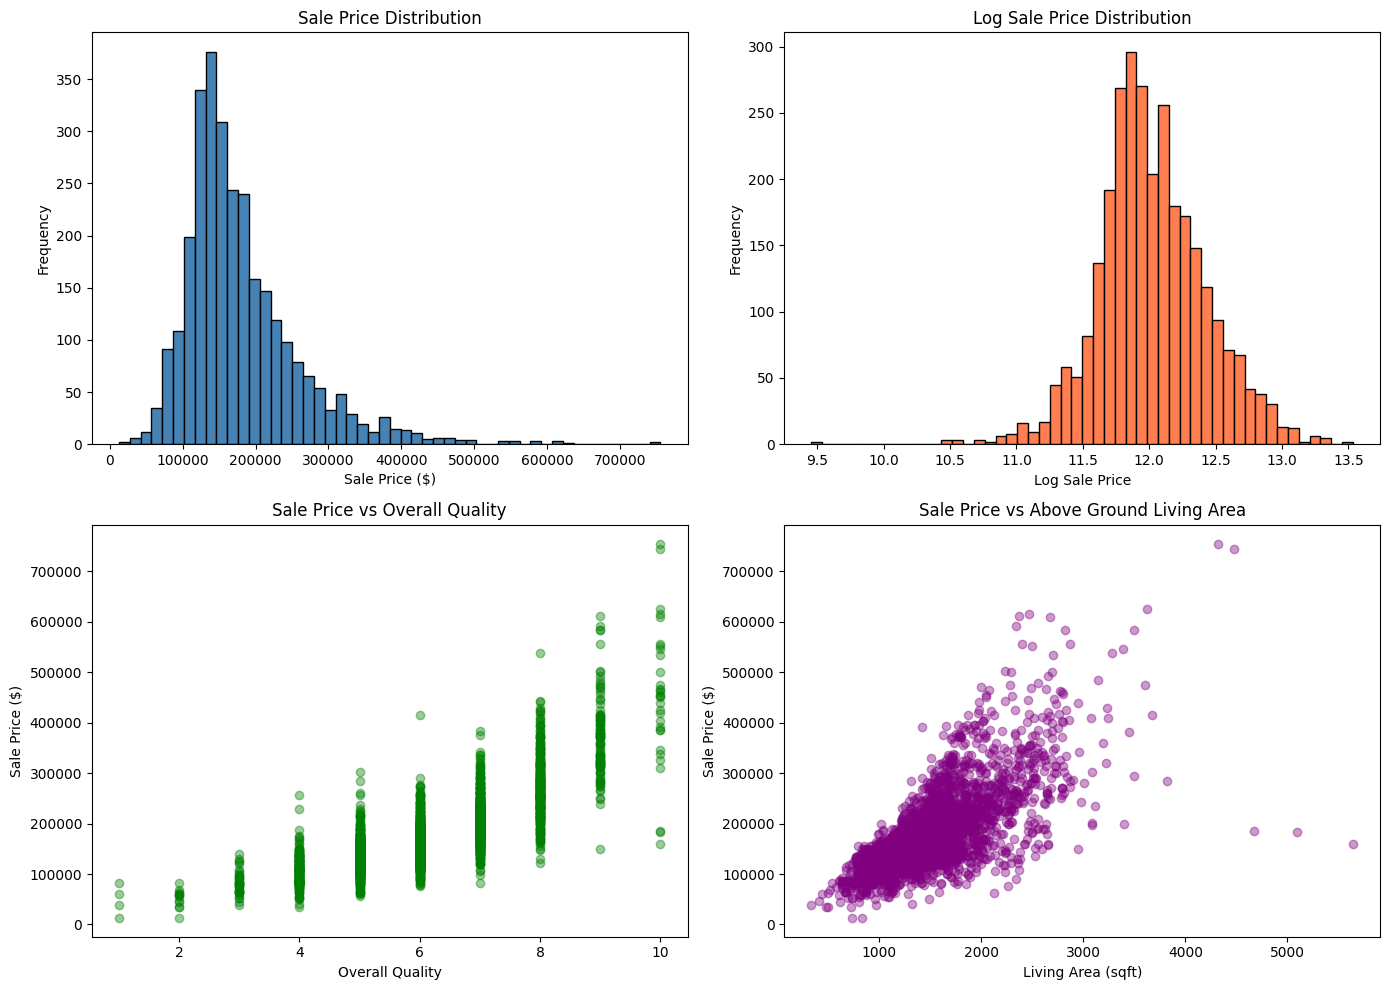

EDA plots saved


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sale Price Distribution
axes[0,0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Sale Price Distribution')
axes[0,0].set_xlabel('Sale Price ($)')
axes[0,0].set_ylabel('Frequency')

# 2. Log Sale Price Distribution
axes[0,1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='black')
axes[0,1].set_title('Log Sale Price Distribution')
axes[0,1].set_xlabel('Log Sale Price')
axes[0,1].set_ylabel('Frequency')

# 3. Sale Price vs Overall Quality
axes[1,0].scatter(df['Overall Qual'], df['SalePrice'], alpha=0.4, color='green')
axes[1,0].set_title('Sale Price vs Overall Quality')
axes[1,0].set_xlabel('Overall Quality')
axes[1,0].set_ylabel('Sale Price ($)')

# 4. Sale Price vs GrLivArea
axes[1,1].scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.4, color='purple')
axes[1,1].set_title('Sale Price vs Above Ground Living Area')
axes[1,1].set_xlabel('Living Area (sqft)')
axes[1,1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved")

In [19]:
# Drop ID columns
df = df.drop(columns=['Order', 'PID'])

# Separate target
y = np.log1p(df['SalePrice'].values)  # log transform
df = df.drop(columns=['SalePrice'])

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('None')
    else:
        df[col] = df[col].fillna(0)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df.values)

# Train/val/test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Preprocessing complete")

Train: (2051, 79), Val: (439, 79), Test: (440, 79)
Preprocessing complete


In [20]:
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = HousingDataset(X_train, y_train)
val_dataset   = HousingDataset(X_val, y_val)
test_dataset  = HousingDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders ready")

DataLoaders ready


In [21]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super(TabularMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

input_dim = X_train.shape[1]
model = TabularMLP(input_dim).cuda()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TabularMLP(
  (network): Sequential(
    (0): Linear(in_features=79, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 207,105


In [22]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.cuda(), y_batch.cuda()
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.cuda(), y_batch.cuda()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

# Train
EPOCHS = 200
train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_tabular_model.pt')

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\nTraining complete")

Epoch [20/200] Train Loss: 1.4669 | Val Loss: 0.4857
Epoch [40/200] Train Loss: 1.0973 | Val Loss: 0.5923
Epoch [60/200] Train Loss: 0.9685 | Val Loss: 0.3391
Epoch [80/200] Train Loss: 0.9840 | Val Loss: 0.3214
Epoch [100/200] Train Loss: 0.8604 | Val Loss: 0.3122
Epoch [120/200] Train Loss: 0.8727 | Val Loss: 0.3032
Epoch [140/200] Train Loss: 0.8682 | Val Loss: 0.2787
Epoch [160/200] Train Loss: 0.8582 | Val Loss: 0.3396
Epoch [180/200] Train Loss: 0.9149 | Val Loss: 0.3827
Epoch [200/200] Train Loss: 0.8548 | Val Loss: 0.2945

Training complete


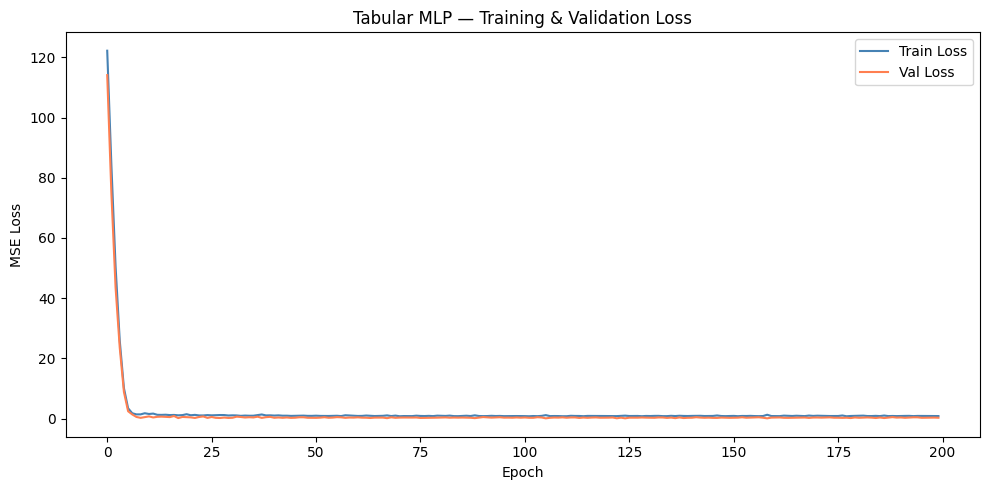

Loss curve saved


In [23]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses, label='Val Loss', color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Tabular MLP — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('tabular_loss_curve.png', dpi=150)
plt.show()
print("Loss curve saved")

In [24]:
# Load best model
model.load_state_dict(torch.load('best_tabular_model.pt'))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.cuda()
        preds = model(X_batch).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

# Convert back from log scale
all_preds = np.expm1(np.array(all_preds))
all_targets = np.expm1(np.array(all_targets))

rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae = mean_absolute_error(all_targets, all_preds)
r2 = r2_score(all_targets, all_preds)

print("=== Tabular MLP Results ===")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f}")

=== Tabular MLP Results ===
RMSE: $66,129.67
MAE:  $44,145.22
R²:   0.3933
